In [7]:
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os
import time
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

BASE = Path.cwd().resolve()
if BASE.name == "notebook":
    BASE = BASE.parent

SRC_DIR   = BASE / "src"
# ==============================================================================
# !!! WARNING - MANDATORY CONFIGURATION BEFORE RUNNING THIS NOTEBOOK !!!
#
# DATA_DIR is an ABSOLUTE path hardcoded to the original author's machine.
# EVERY USER MUST REPLACE IT with their own local path to the folder that
# contains the ~3,000 daily option CSVs (FullOptionData/, one file per
# trading date, e.g. 20100104.csv ... 20201231.csv).
#
# If you do not change it, the notebook will stop at Step 2 with:
#   RuntimeError: No CSV files found in: <path that does not exist on your PC>
# ==============================================================================
DATA_DIR  = Path(r"C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO\FullOptionData")  # <-- CHANGE THIS to your local path
OUTPUT_DIR = BASE / "output"
PLOT_DIR  = OUTPUT_DIR / "plots"
CACHE_DIR = OUTPUT_DIR / "cache"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

PROGETTO_FINAL = Path(r"C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO_FINAL")
OUT_PATH    = PROGETTO_FINAL / "FullOptionDatasetEngineered.csv"
RATES_CACHE = CACHE_DIR  / "_cache_rates.csv"

REF_DATE  = pd.Timestamp("2010-01-04")
DATE_FROM = pd.Timestamp("2010-01-01")
DATE_TO   = pd.Timestamp("2020-12-31")

print(f"Data source : {DATA_DIR}")
print(f"Output      : {OUT_PATH}")
print(f"Window      : {DATE_FROM.date()} → {DATE_TO.date()}")
print(f"Reference   : {REF_DATE.date()} (time_elapsed = 0)")

Data source : C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO\FullOptionData
Output      : C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO_FINAL\FullOptionDatasetEngineered.csv
Window      : 2010-01-01 → 2020-12-31
Reference   : 2010-01-04 (time_elapsed = 0)


## Step 1 — Discover CSV Files for 2010–2020

In [8]:
def date_from_fname(path):
    for fmt in ("%Y%m%d", "%Y-%m-%d"):
        try:
            return pd.to_datetime(path.stem, format=fmt)
        except ValueError:
            pass
    return None

all_files    = sorted(DATA_DIR.glob("*.csv"))
valid_files  = [p for p in all_files if date_from_fname(p) is not None]
invalid_files = [p for p in all_files if date_from_fname(p) is None]
print(f"Total CSV files        : {len(all_files)}")
print(f"  Valid (date-named)   : {len(valid_files)}")
print(f"  Ignored (non-date)   : {len(invalid_files)}")

files_in_window = [
    p for p in valid_files
    if DATE_FROM <= date_from_fname(p) <= DATE_TO
]
print(f"Files in 2010-2020 window: {len(files_in_window)}")

if not files_in_window:
    raise RuntimeError(
        f"No CSV files found in:\n  {DATA_DIR}\n"
        "Check that DATA_DIR is correct and the folder contains date-named CSVs."
    )

print(f"First : {files_in_window[0].name}")
print(f"Last  : {files_in_window[-1].name}")

Total CSV files        : 3322
  Valid (date-named)   : 3322
  Ignored (non-date)   : 0
Files in 2010-2020 window: 2769
First : 2010-01-04.csv
Last  : 2020-12-31.csv


## Step 2 — Load and Concatenate All CSVs

Raw columns: `DATE, DATE.1, ASK PRICE, BID PRICE, OPT STRIKE PRICE, OPEN INTEREST,
OPT EXERCISE PRICE, PRICE HIGH, PRICE LOW, OPENING PRICE, Instrument, exp_date, type`

Note: `OPT STRIKE PRICE` is NaN in early years; use `OPT EXERCISE PRICE` as fallback.

In [9]:
KEEP_COLS = ["DATE", "ASK PRICE", "BID PRICE", "OPT STRIKE PRICE",
             "OPT EXERCISE PRICE", "OPEN INTEREST", "Instrument", "exp_date", "type"]

def load_one(path):
    try:
        df = pd.read_csv(path, parse_dates=["DATE", "exp_date"], low_memory=False)
        df.columns = df.columns.str.strip()
        # Drop duplicate DATE column if present (sometimes named DATE.1)
        df = df.loc[:, ~df.columns.duplicated()]
        # Keep only columns we need (ignore missing ones gracefully)
        keep = [c for c in KEEP_COLS if c in df.columns]
        return df[keep]
    except Exception as e:
        print(f"[WARN] {os.path.basename(path)}: {e}")
        return None

t0 = time.time()
chunks = []
for i, path in enumerate(files_in_window):
    chunk = load_one(path)
    if chunk is not None:
        chunks.append(chunk)
    if (i + 1) % 500 == 0:
        print(f"  Loaded {i+1}/{len(files_in_window)} files  "
              f"({sum(len(c) for c in chunks):,} rows so far) …")

df_raw = pd.concat(chunks, ignore_index=True)
print(f"\nLoaded {len(files_in_window)} files in {time.time()-t0:.1f}s")
print(f"Raw combined: {len(df_raw):,} rows x {len(df_raw.columns)} columns")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

  Loaded 500/2769 files  (168,541 rows so far) …
  Loaded 1000/2769 files  (494,059 rows so far) …
  Loaded 1500/2769 files  (1,041,357 rows so far) …
  Loaded 2000/2769 files  (1,678,880 rows so far) …
  Loaded 2500/2769 files  (2,642,135 rows so far) …

Loaded 2769 files in 32.1s
Raw combined: 3,331,302 rows x 9 columns
Columns: ['DATE', 'ASK PRICE', 'BID PRICE', 'OPT STRIKE PRICE', 'OPT EXERCISE PRICE', 'OPEN INTEREST', 'Instrument', 'exp_date', 'type']


,DATE,ASK PRICE,BID PRICE,OPT STRIKE PRICE,OPT EXERCISE PRICE,OPEN INTEREST,Instrument,exp_date,type
0,2010-01-04,131.7,125.7,NaN,1100,4448.0,SPX06111100C,2011-06-17,C
1,2010-01-04,118.6,112.6,NaN,1100,10141.0,SPX06111100P,2011-06-17,P
2,2010-01-04,118.1,112.1,NaN,1125,3651.0,SPX06111125C,2011-06-17,C


## Step 3 — Clean and Engineer Base Features

In [10]:
# ── Coalesce strike price (NaN in early years → use OPT EXERCISE PRICE) ──────
if "OPT EXERCISE PRICE" in df_raw.columns:
    df_raw["OPT STRIKE PRICE"] = df_raw["OPT STRIKE PRICE"].combine_first(
        df_raw["OPT EXERCISE PRICE"]
    )
    df_raw.drop(columns=["OPT EXERCISE PRICE"], inplace=True)

# ── Parse dates robustly ──────────────────────────────────────────────────────
df_raw["DATE"]     = pd.to_datetime(df_raw["DATE"],     errors="coerce")
df_raw["exp_date"] = pd.to_datetime(df_raw["exp_date"], errors="coerce")

# ── Derived features ──────────────────────────────────────────────────────────
df_raw["Mid Price"]       = (df_raw["ASK PRICE"] + df_raw["BID PRICE"]) / 2
df_raw["Liquidity Factor"] = ((df_raw["ASK PRICE"] - df_raw["BID PRICE"])
                               / df_raw["Mid Price"].replace(0, np.nan))
df_raw["OptionType"]      = df_raw["type"].str.upper().map({"C": 1, "P": -1})

# TTE in years (calendar days / 365)
df_raw["TTE"] = (df_raw["exp_date"] - df_raw["DATE"]).dt.days / 365.0

# Time Elapsed: calendar days from reference date
df_raw["Time Elapsed"] = (df_raw["DATE"] - REF_DATE).dt.days

print(f"Rows before any filtering: {len(df_raw):,}")
print(f"Date range: {df_raw['DATE'].min().date()} → {df_raw['DATE'].max().date()}")
df_raw[["DATE","OPT STRIKE PRICE","Mid Price","Liquidity Factor",
        "OptionType","TTE","Time Elapsed"]].head(4)

Rows before any filtering: 3,331,302
Date range: 2010-01-04 → 2020-12-31


,DATE,OPT STRIKE PRICE,Mid Price,Liquidity Factor,OptionType,TTE,Time Elapsed
0,2010-01-04,1100.0,128.7,0.046620,1,1.449315,0
1,2010-01-04,1100.0,115.6,0.051903,-1,1.449315,0
2,2010-01-04,1125.0,115.1,0.052129,1,1.449315,0
3,2010-01-04,1125.0,126.7,0.047356,-1,1.449315,0


## Step 4 — Implied Spot from Put-Call Parity (no external download)

Rather than fetching the SP500 closing price from yfinance, we extract the
**implied forward price** directly from the options data via put-call parity:

$$C_{mid} - P_{mid} \approx F - K \quad (\text{ignoring discount for simplicity})$$

For each date, we match call/put pairs with the same *(date, strike, expiry)*,
compute the implied forward $\hat{F} = K + C_{mid} - P_{mid}$ for each pair,
and take the **median across all matched pairs** per date as the daily implied spot.

This approach:
- Requires **no external data** (SP500, yfinance)
- Is **self-consistent** with the put-call parity computation in notebook 01
- The stored `sp500` column actually represents the options-implied forward level,
  which is exactly what notebook 01 re-computes more precisely with discounting.

> Note: notebook 01 will re-derive the forward rigorously (with risk-free rates
> and OI weighting). The `sp500` column here is only used for the initial broad
> spot-moneyness filter (−0.40 to +0.30) to remove extremely far OTM/ITM quotes.


In [11]:
print("Step 4 — Computing implied spot from call/put pairs (put-call parity)")
print("="*65)

# Separate calls and puts
df_c = df_raw[df_raw["OptionType"] == 1][["DATE","OPT STRIKE PRICE","exp_date","Mid Price"]].copy()
df_p = df_raw[df_raw["OptionType"] ==-1][["DATE","OPT STRIKE PRICE","exp_date","Mid Price"]].copy()

df_c.rename(columns={"Mid Price": "C_mid"}, inplace=True)
df_p.rename(columns={"Mid Price": "P_mid"}, inplace=True)

# Match on (date, strike, expiry)
pairs = df_c.merge(df_p, on=["DATE","OPT STRIKE PRICE","exp_date"], how="inner")
pairs["F_implied"] = pairs["OPT STRIKE PRICE"] + pairs["C_mid"] - pairs["P_mid"]

# Keep only sensible forward estimates (> 0, within 50% of strike)
pairs = pairs[
    (pairs["F_implied"] > 0) &
    (pairs["F_implied"] / pairs["OPT STRIKE PRICE"]).between(0.5, 2.0)
]

# Median implied forward per date (robust to outliers)
sp500_implied = (pairs.groupby("DATE")["F_implied"]
                 .median()
                 .reset_index()
                 .rename(columns={"F_implied": "sp500"}))

n_dates = len(sp500_implied)
print(f"Matched call/put pairs   : {len(pairs):,}")
print(f"Dates with implied spot  : {n_dates}")
print(f"Implied spot range       : {sp500_implied['sp500'].min():.0f} – "
      f"{sp500_implied['sp500'].max():.0f}")
print()
print("Sample (first 5 dates):")
print(sp500_implied.head().to_string(index=False))

Step 4 — Computing implied spot from call/put pairs (put-call parity)
Matched call/put pairs   : 1,502,510
Dates with implied spot  : 2769
Implied spot range       : 1004 – 3725

Sample (first 5 dates):
      DATE   sp500
2010-01-04 1117.05
2010-01-05 1119.80
2010-01-06 1119.90
2010-01-07 1124.50
2010-01-08 1127.80


## Step 5 — Fetch US Treasury Rates (FRED via `fredapi`)

Tickers: `DGS1MO` (1m), `DGS3MO` (3m), `DGS6MO` (6m), `DGS1` (1y), `DGS2` (2y), `DGS3` (3y).
FRED values are in **percent per annum** — same unit as the original dataset.

> **!!! REQUIRED — FRED API KEY !!!** This step uses the `fredapi` package rather than `pandas_datareader`
> (whose anonymous public endpoint proved unreliable — frequent connection timeouts / `504 Gateway Time-out`
> from FRED's own servers). `fredapi` requires a **free personal API key**.
>
> **EVERY USER MUST INSERT THEIR OWN KEY** in the `FRED_API_KEY` variable in the cell below, replacing
> the placeholder string. Register for a free key at: https://fred.stlouisfed.org/docs/api/api_key.html
>
> Do not share your key and do not commit your real key to a public git repository.

In [13]:
RATES_CACHE = CACHE_DIR / "_cache_rates.csv"

FRED_TICKERS = {
    "DGS1MO": "rate1month",
    "DGS3MO": "rate3month",
    "DGS6MO": "rate6month",
    "DGS1"  : "rate1year",
    "DGS2"  : "rate2year",
    "DGS3"  : "rate3year",
}

# ==============================================================================
# !!! REQUIRED CONFIGURATION — INSERT YOUR PERSONAL FRED API KEY HERE !!!
#
# EVERY USER MUST REPLACE THE PLACEHOLDER BELOW WITH THEIR OWN FREE FRED API KEY.
# Register at: https://fred.stlouisfed.org/docs/api/api_key.html
#
# Do not share your key and do not commit your real key to a public repository
# (e.g. keep this notebook's diff local, or load the key from an environment
# variable / untracked config file instead of hardcoding it).
# ==============================================================================
FRED_API_KEY = '443c959d542fb3328af50453afd7368a'   # <-- INSERT YOUR PERSONAL FRED API KEY

def fetch_rates(start="2009-12-01", end="2021-01-10"):
    if os.path.exists(RATES_CACHE):
        df = pd.read_csv(RATES_CACHE, parse_dates=["Date"], index_col="Date")
        print(f"Rates loaded from cache ({len(df)} rows)")
        return df
    if not FRED_API_KEY or FRED_API_KEY == "PASTE_YOUR_FRED_API_KEY_HERE":
        raise RuntimeError(
            "FRED_API_KEY is not set. Register for a free personal key at "
            "https://fred.stlouisfed.org/docs/api/api_key.html and paste it into "
            "the FRED_API_KEY variable above before running this cell."
        )
    try:
        from fredapi import Fred
        fred = Fred(api_key=FRED_API_KEY)
        series = {col: fred.get_series(ticker, observation_start=start, observation_end=end)
                  for ticker, col in FRED_TICKERS.items()}
        raw = pd.DataFrame(series)
        raw.index.name = "Date"
        # Forward-fill weekends/holidays (FRED publishes business days only)
        raw = raw.ffill()
        raw.to_csv(RATES_CACHE)
        print(f"Rates downloaded from FRED: {len(raw)} rows")
        return raw
    except Exception as e:
        raise RuntimeError(
            f"FRED Treasury-rate download failed ({e!r}). "
            "Cannot proceed: the put-call-parity forward computation in notebook 01 "
            "requires valid rates — continuing with NaN placeholders would silently "
            "corrupt FullOptionDatasetEngineered.csv and break the pipeline several "
            "steps downstream with a cryptic merge-dtype error. Check your internet "
            "connection, that 'fredapi' is installed (pip install fredapi), and that "
            "FRED_API_KEY above is set to your own valid personal key, then re-run this cell."
        ) from e

rates_df = fetch_rates()
if rates_df is not None:
    print(rates_df.head(3))

Rates downloaded from FRED: 2899 rows
            rate1month  rate3month  rate6month  rate1year  rate2year  \
Date                                                                   
2009-12-01        0.09        0.06        0.15       0.26       0.67   
2009-12-02        0.08        0.05        0.15       0.28       0.72   
2009-12-03        0.09        0.06        0.16       0.30       0.74   

            rate3year  
Date                   
2009-12-01       1.14  
2009-12-02       1.19  
2009-12-03       1.23  


## Step 6 — Merge Implied Spot and Rates into Option Data

In [14]:
df = df_raw.copy()

# ── Merge implied spot (from put-call parity) ─────────────────────────────────
if len(sp500_implied) > 0:
    sp500_implied["DATE"] = pd.to_datetime(sp500_implied["DATE"])
    df = df.merge(sp500_implied, on="DATE", how="left")
    # Forward-fill for any dates without matched pairs
    df["sp500"] = df["sp500"].ffill()
    null_sp = df["sp500"].isna().sum()
    print(f"Implied spot merged. Null count: {null_sp:,}")
    if null_sp > 0:
        # Fill remaining nulls with rolling median of strike (very rough fallback)
        df["sp500"] = df["sp500"].fillna(df["OPT STRIKE PRICE"].median())
        print(f"  Filled {null_sp:,} nulls with dataset-wide median strike")
else:
    print("[WARN] No matched call/put pairs — using OPT STRIKE PRICE median as fallback")
    df["sp500"] = df["OPT STRIKE PRICE"].median()

# ── Merge Treasury rates ──────────────────────────────────────────────────────
# rates_df is guaranteed non-None here: fetch_rates() raises on failure (see Step 5)
# rather than returning None, so we never silently merge in an all-NaN rate block.
rate_cols = list(FRED_TICKERS.values())
rates_daily = rates_df[rate_cols].reset_index()
rates_daily.columns = ["DATE"] + rate_cols
rates_daily["DATE"] = pd.to_datetime(rates_daily["DATE"])
df = df.merge(rates_daily, on="DATE", how="left")
for col in rate_cols:
    df[col] = df[col].ffill()
null_rates = df[rate_cols].isna().sum().sum()
print(f"Rates merged. Total null rate cells: {null_rates}")

# Guard: if the date alignment left a rate column entirely NaN, fail loudly now —
# clean_options() in notebook 01 requires these columns and would otherwise drop
# every single row, surfacing only as a confusing merge-dtype error far downstream.
fully_nan_rates = [c for c in rate_cols if df[c].isna().all()]
if fully_nan_rates:
    raise RuntimeError(
        f"Rate columns are entirely NaN after merge: {fully_nan_rates}. "
        "This would silently corrupt FullOptionDatasetEngineered.csv. "
        "Delete the stale cache at " + str(RATES_CACHE) + " and re-run Step 5 "
        "(FRED download) before continuing."
    )

# Spot moneyness = log(K / implied_spot)  — used only for initial broad filter
df["Moneyness"] = np.log(df["OPT STRIKE PRICE"] / df["sp500"])

print(f"\nAfter merge: {len(df):,} rows")
df[["DATE","OPT STRIKE PRICE","sp500","Moneyness","rate1month","rate3year"]].head(3)

Implied spot merged. Null count: 0
Rates merged. Total null rate cells: 0

After merge: 3,331,302 rows


,DATE,OPT STRIKE PRICE,sp500,Moneyness,rate1month,rate3year
0,2010-01-04,1100.0,1117.05,-0.015381,0.05,1.66
1,2010-01-04,1100.0,1117.05,-0.015381,0.05,1.66
2,2010-01-04,1125.0,1117.05,0.007092,0.05,1.66


## Step 7 — Quality Filters

Same filter chain as the original pipeline (notebook 01):
- Mid Price > 0.05
- TTE > 7 days (>0.0192 years)
- Liquidity Factor ≤ 0.30
- Spot moneyness ∈ [−0.40, 0.30]
- Strike > 0, SP500 > 0

In [15]:
n0 = len(df)
print(f"Before filters: {n0:,}")

df = df.dropna(subset=["DATE","exp_date","OPT STRIKE PRICE","Mid Price",
                        "OptionType","TTE","sp500","Moneyness"])
print(f"After dropna    : {len(df):,}  (removed {n0-len(df):,})")

df = df[df["Mid Price"] > 0.05];           print(f"Mid>0.05        : {len(df):,}")
df = df[df["TTE"] > 7/365];                print(f"TTE>7d          : {len(df):,}")
df = df[df["Liquidity Factor"] <= 0.30];   print(f"LF<=0.30        : {len(df):,}")
df = df[df["Moneyness"].between(-0.40, 0.30)]
print(f"Moneyness filter: {len(df):,}")
df = df[df["OPT STRIKE PRICE"] > 0];      print(f"Strike>0        : {len(df):,}")

df = df.reset_index(drop=True)
n_dates = df["DATE"].nunique()
print(f"\nFinal: {len(df):,} rows  |  {n_dates} unique trading dates")
print(f"Date range: {df['DATE'].min().date()} → {df['DATE'].max().date()}")

Before filters: 3,331,302
After dropna    : 3,331,302  (removed 0)
Mid>0.05        : 3,331,292
TTE>7d          : 3,285,718
LF<=0.30        : 3,011,248
Moneyness filter: 2,324,008
Strike>0        : 2,324,008

Final: 2,324,008 rows  |  2769 unique trading dates
Date range: 2010-01-04 → 2020-12-31


## Step 8 — Assemble Final Schema

Output columns match `Dati Optionsdsfinal.csv` exactly so the downstream notebooks (01, 02, and beyond) work unchanged.

In [16]:
FINAL_COLS = [
    "Time Elapsed", "OPT STRIKE PRICE", "OPEN INTEREST", "Instrument",
    "Mid Price", "Liquidity Factor", "OptionType",
    "rate3year", "rate2year", "rate1year", "rate6month", "rate3month", "rate1month",
    "sp500", "Moneyness", "TTE",
]

# Ensure all columns exist (fill missing with NaN)
for col in FINAL_COLS:
    if col not in df.columns:
        print(f"[WARN] Column '{col}' missing — filling with NaN")
        df[col] = np.nan

df_final = df[FINAL_COLS].copy()
df_final["Time Elapsed"]    = df_final["Time Elapsed"].astype(int)
df_final["OPT STRIKE PRICE"] = df_final["OPT STRIKE PRICE"].astype(float)
df_final["OPEN INTEREST"]   = df_final["OPEN INTEREST"].astype(float)
df_final["OptionType"]      = df_final["OptionType"].astype(int)

df_final = df_final.sort_values(["Time Elapsed","OPT STRIKE PRICE"]).reset_index(drop=True)

print(f"Final dataset: {len(df_final):,} rows x {len(df_final.columns)} columns")
print(f"Time Elapsed: {df_final['Time Elapsed'].min()} → {df_final['Time Elapsed'].max()}")
print(f"  (= {REF_DATE.date()} + {df_final['Time Elapsed'].min()}d "
      f"→ {REF_DATE.date()} + {df_final['Time Elapsed'].max()}d)")
print(f"Trading days: {df_final['Time Elapsed'].nunique()}")
print()
df_final.describe()

Final dataset: 2,324,008 rows x 16 columns
Time Elapsed: 0 → 4014
  (= 2010-01-04 + 0d → 2010-01-04 + 4014d)
Trading days: 2769



,Time Elapsed,OPT STRIKE PRICE,OPEN INTEREST,Mid Price,Liquidity Factor,OptionType,rate3year,rate2year,rate1year,rate6month,rate3month,rate1month,sp500,Moneyness,TTE
count,2.324008e+06,2.324008e+06,2.316709e+06,2.324008e+06,2.324008e+06,2.324008e+06,2.324008e+06,2.324008e+06,2.324008e+06,2.324008e+06,2.324008e+06,2.324008e+06,2.324008e+06,2.324008e+06,2.324008e+06
mean,2.589692e+03,2.272042e+03,6.590749e+03,2.481138e+02,4.670573e-02,-3.913842e-02,1.227471e+00,1.073603e+00,9.222922e-01,8.515615e-01,7.819907e-01,7.466894e-01,2.399114e+03,-6.149021e-02,8.853521e-01
std,1.027096e+03,6.824358e+02,1.509053e+04,2.434607e+02,5.330564e-02,9.992340e-01,7.915206e-01,8.374366e-01,8.843782e-01,8.850689e-01,8.744222e-01,8.625905e-01,6.365193e+02,1.711127e-01,7.338202e-01
min,0.000000e+00,8.750000e+02,0.000000e+00,1.000000e-01,-1.997401e+00,-1.000000e+00,1.000000e-01,1.100000e-01,8.000000e-02,2.000000e-02,0.000000e+00,0.000000e+00,1.003737e+03,-3.999978e-01,2.191781e-02
25%,1.799000e+03,1.725000e+03,6.000000e+00,4.970000e+01,1.277014e-02,-1.000000e+00,6.000000e-01,3.400000e-01,1.500000e-01,1.100000e-01,7.000000e-02,5.000000e-02,1.951000e+03,-1.960149e-01,2.876712e-01
50%,2.776000e+03,2.200000e+03,7.980000e+02,1.674500e+02,2.622951e-02,-1.000000e+00,1.040000e+00,7.500000e-01,5.100000e-01,3.900000e-01,2.400000e-01,1.900000e-01,2.441025e+03,-4.941769e-02,6.931507e-01
75%,3.495000e+03,2.750000e+03,6.033000e+03,3.825500e+02,5.878332e-02,1.000000e+00,1.650000e+00,1.630000e+00,1.620000e+00,1.610000e+00,1.580000e+00,1.570000e+00,2.891550e+03,7.239476e-02,1.273973e+00
max,4.014000e+03,4.075000e+03,2.970780e+05,1.350000e+03,3.000000e-01,1.000000e+00,3.050000e+00,2.980000e+00,2.740000e+00,2.580000e+00,2.490000e+00,2.510000e+00,3.725100e+03,2.999946e-01,2.997260e+00


## Step 9 — Save `FullOptionDatasetEngineered.csv`

In [17]:
df_final.to_csv(OUT_PATH, index=False)
size_mb = os.path.getsize(OUT_PATH) / 1e6

print(f"Saved: {OUT_PATH}")
print(f"Size : {size_mb:.1f} MB")
print(f"Rows : {len(df_final):,}")
print(f"Cols : {list(df_final.columns)}")
print()
print("Dataset statistics:")
print(f"  Calls   : {(df_final['OptionType']==1).sum():,}  "
      f"({(df_final['OptionType']==1).mean():.1%})")
print(f"  Puts    : {(df_final['OptionType']==-1).sum():,}  "
      f"({(df_final['OptionType']==-1).mean():.1%})")
print(f"  OI mean : {df_final['OPEN INTEREST'].mean():.0f}")
print(f"  TTE range: {df_final['TTE'].min():.3f} → {df_final['TTE'].max():.3f} years")
print(f"  SP500 range: {df_final['sp500'].min():.0f} → {df_final['sp500'].max():.0f}")
print(f"  Moneyness: {df_final['Moneyness'].min():.3f} → {df_final['Moneyness'].max():.3f}")

Saved: C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO_FINAL\FullOptionDatasetEngineered.csv
Size : 331.5 MB
Rows : 2,324,008
Cols : ['Time Elapsed', 'OPT STRIKE PRICE', 'OPEN INTEREST', 'Instrument', 'Mid Price', 'Liquidity Factor', 'OptionType', 'rate3year', 'rate2year', 'rate1year', 'rate6month', 'rate3month', 'rate1month', 'sp500', 'Moneyness', 'TTE']

Dataset statistics:
  Calls   : 1,116,525  (48.0%)
  Puts    : 1,207,483  (52.0%)
  OI mean : 6591
  TTE range: 0.022 → 2.997 years
  SP500 range: 1004 → 3725
  Moneyness: -0.400 → 0.300


## Step 10 — Diagnostic Plots

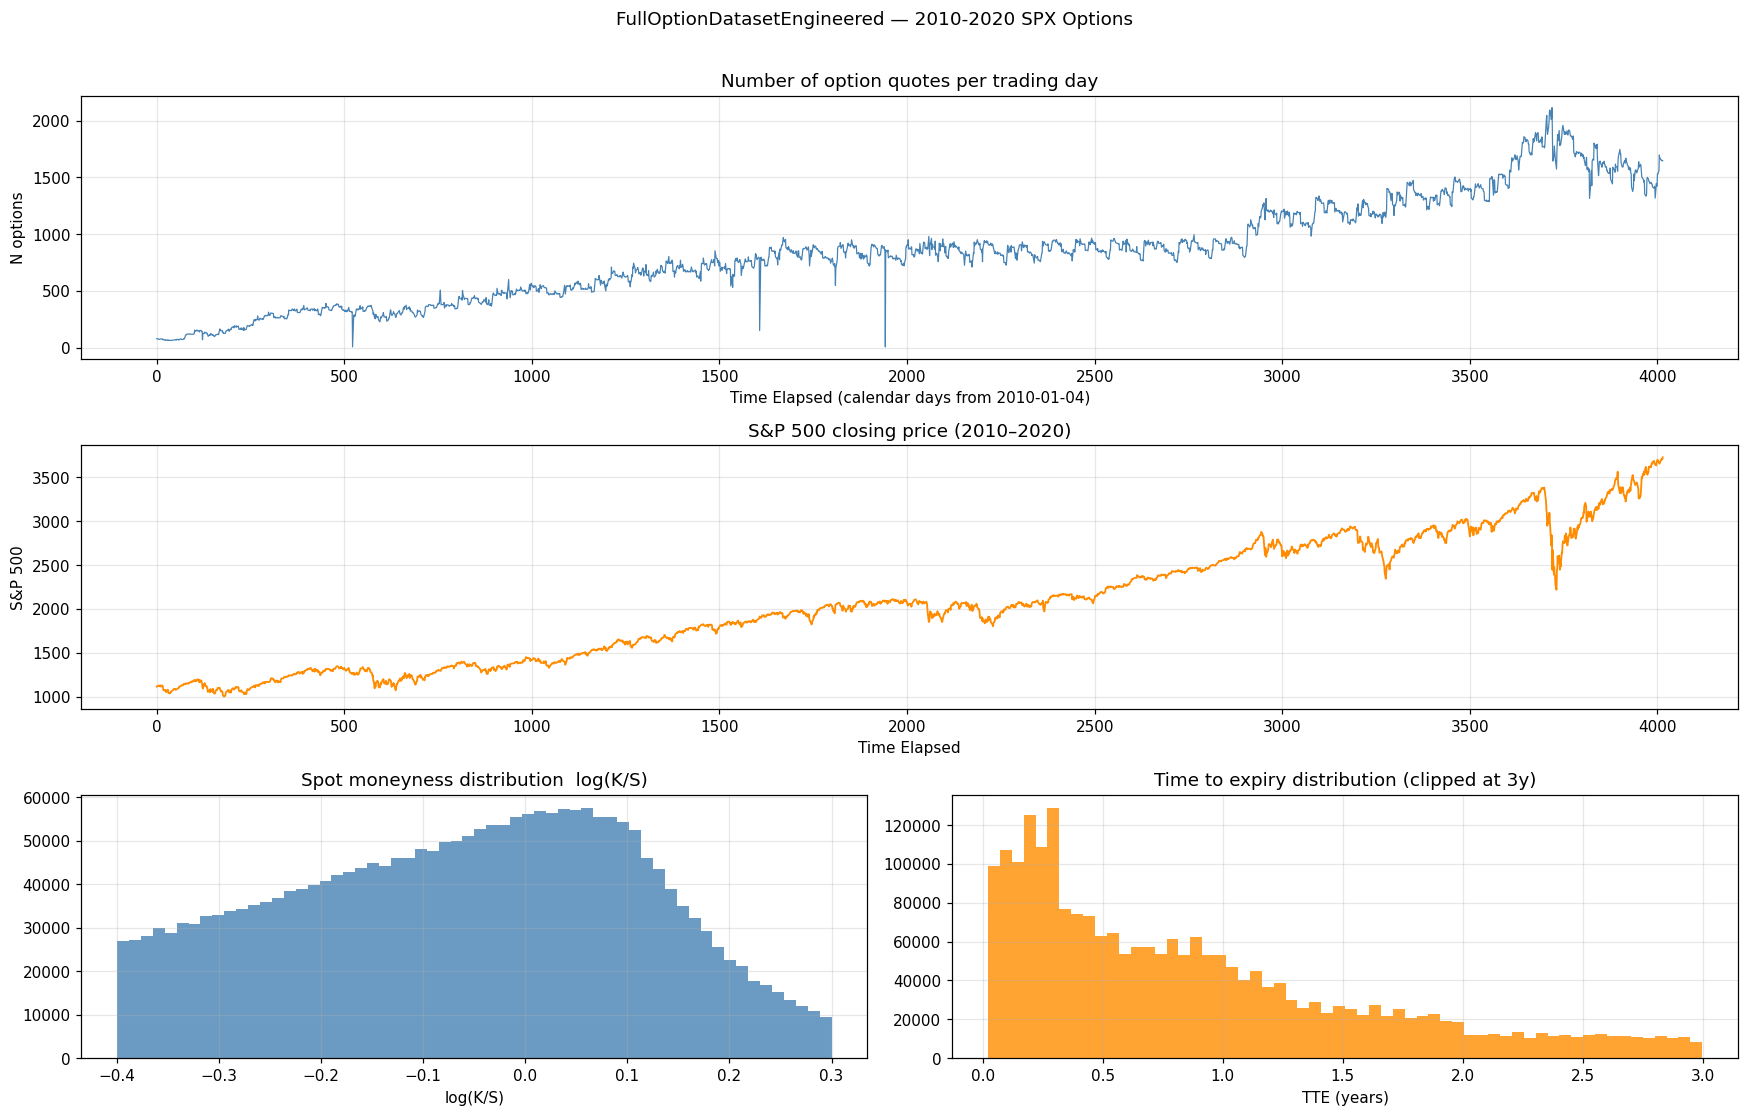

Diagnostic plot saved.


In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Options per trading day
daily_counts = (df_final.groupby("Time Elapsed")
                .size().reset_index(name="n_options"))
# SP500 per trading day (first quote per date suffices)
daily_sp = (df_final.groupby("Time Elapsed")["sp500"].first()
            .reset_index())

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig)

ax0 = fig.add_subplot(gs[0, :])
ax0.plot(daily_counts["Time Elapsed"], daily_counts["n_options"],
         lw=0.8, color="steelblue")
ax0.set_title("Number of option quotes per trading day")
ax0.set_xlabel("Time Elapsed (calendar days from 2010-01-04)")
ax0.set_ylabel("N options")
ax0.grid(True, alpha=0.3)

ax1 = fig.add_subplot(gs[1, :])
ax1.plot(daily_sp["Time Elapsed"], daily_sp["sp500"],
         lw=1.2, color="darkorange")
ax1.set_title("S&P 500 closing price (2010–2020)")
ax1.set_ylabel("S&P 500")
ax1.set_xlabel("Time Elapsed")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[2, 0])
ax2.hist(df_final["Moneyness"], bins=60, color="steelblue", alpha=0.8)
ax2.set_title("Spot moneyness distribution  log(K/S)")
ax2.set_xlabel("log(K/S)"); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[2, 1])
ax3.hist(df_final["TTE"].clip(upper=3), bins=60, color="darkorange", alpha=0.8)
ax3.set_title("Time to expiry distribution (clipped at 3y)")
ax3.set_xlabel("TTE (years)"); ax3.grid(True, alpha=0.3)

plt.suptitle("FullOptionDatasetEngineered — 2010-2020 SPX Options", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / "00_dataset_overview.png", dpi=120,
            bbox_inches="tight")
plt.show()
print("Diagnostic plot saved.")

## Summary

| Item | Value |
|------|-------|
| Source | `FullOptionData/` (3 322 per-day CSVs) |
| Window | 2010-01-01 → 2020-12-31 |
| Reference date | `2010-01-04` (Time Elapsed = 0) |
| Output file | `output/FullOptionDatasetEngineered.csv` |
| Schema | Identical to original `Dati Optionsdsfinal.csv` |

**Next step**: Run `01_iv_dataset_construction.ipynb` to compute forward prices and
Black-76 implied volatilities → `output/options_with_forward_iv_clean.csv`.
Then run `02_ssvi_calibration.ipynb` to calibrate the daily SSVI surfaces — this
completes the data-processing pipeline that feeds the econometric analyses (notebooks A-D)
and the supplementary studies (S1, S2).